# CoinMarketCap monthly top 10 by market cap

Notebook builds a monthly bump chart for the top 10 crypto assets by market capitalization over the last 6 years. It does not save images; the chart is rendered inline.

In [87]:
import datetime as dt
import json
import re
import time
from collections.abc import Iterable

import matplotlib.pyplot as plt
import pandas as pd
import requests
from bs4 import BeautifulSoup

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 40)

In [88]:
# Settings
START_DATE = pd.Timestamp("2020-01-01").date()
END_DATE = pd.Timestamp("2026-03-01").date()

# CoinMarketCap historical pages are snapshots by date: /historical/YYYYMMDD/
SNAPSHOT_LIMIT = 110
REQUEST_SLEEP_SECONDS = 1.0
REQUEST_TIMEOUT = 30
REQUEST_RETRIES = 5
REQUEST_BACKOFF_SECONDS = 3.0

print(f"Monthly snapshots from {START_DATE} to {END_DATE}")

Monthly snapshots from 2020-01-01 to 2026-03-01


In [89]:
def monthly_snapshot_dates(start_date, end_date) -> list[dt.date]:
    start = pd.Timestamp(start_date)
    end = pd.Timestamp(end_date)
    first_month_start = (start + pd.offsets.MonthBegin(1)).normalize()
    dates = pd.date_range(first_month_start, end, freq="MS")
    return [d.date() for d in dates]


def parse_cmc_number(value):
    if value is None:
        return None
    text = str(value).strip()
    if not text or text in {"--", "-", "?"}:
        return None

    multiplier = 1.0
    suffix_match = re.search(r"([KMBT])\s*$", text, flags=re.IGNORECASE)
    if suffix_match:
        suffix = suffix_match.group(1).upper()
        multiplier = {"K": 1e3, "M": 1e6, "B": 1e9, "T": 1e12}[suffix]

    cleaned = re.sub(r"[^0-9.\-]", "", text)
    if cleaned in {"", ".", "-"}:
        return None
    try:
        return float(cleaned) * multiplier
    except ValueError:
        return None


def normalize_header(value: str) -> str:
    text = re.sub(r"\s+", " ", str(value).strip().lower())
    text = text.replace("#", "rank")
    text = text.replace("market cap", "market_cap")
    text = text.replace("volume (24h)", "volume_24h")
    text = text.replace("volume 24h", "volume_24h")
    text = text.replace(" ", "_")
    text = re.sub(r"[^a-z0-9_]+", "", text)
    return text


def iter_json_objects(obj):
    if isinstance(obj, dict):
        yield obj
        for value in obj.values():
            yield from iter_json_objects(value)
    elif isinstance(obj, list):
        for item in obj:
            yield from iter_json_objects(item)


def has_required_snapshot_columns(df: pd.DataFrame) -> bool:
    return not df.empty and {"symbol", "market_cap"}.issubset(df.columns)


def parse_table_row_by_position(values: list[str]) -> dict:
    values = [str(value).strip() for value in values if str(value).strip()]
    if len(values) < 4:
        return {}

    rank = values[0]
    money_positions = [i for i, value in enumerate(values) if "$" in value]
    if not money_positions:
        return {}

    market_cap_idx = money_positions[0]
    asset_values = values[1:market_cap_idx]
    symbol_candidates = [
        token
        for value in asset_values
        for token in re.findall(r"\b[A-Z0-9]{2,12}\b", value)
    ]
    symbol = symbol_candidates[-1] if symbol_candidates else None
    name = asset_values[0] if asset_values else None

    return {
        "rank": rank,
        "name": name,
        "symbol": symbol,
        "market_cap": values[market_cap_idx],
        "price": values[market_cap_idx + 1] if len(values) > market_cap_idx + 1 else None,
        "volume_24h": values[market_cap_idx + 2] if len(values) > market_cap_idx + 2 else None,
    }

In [90]:
def parse_snapshot_from_table(html: str, snapshot_date: dt.date) -> pd.DataFrame:
    soup = BeautifulSoup(html, "html.parser")
    table_candidates = []
    for candidate in soup.find_all("table"):
        headers_text = " ".join(th.get_text(" ", strip=True).lower() for th in candidate.find_all("th"))
        data_rows = [tr for tr in candidate.find_all("tr") if tr.find_all("td")]
        if data_rows and "market cap" in headers_text and "symbol" in headers_text:
            table_candidates.append((len(data_rows), candidate))

    table = max(table_candidates, key=lambda item: item[0])[1] if table_candidates else None
    if table is None:
        return pd.DataFrame()

    header_cells = table.find_all("th")
    headers = [normalize_header(cell.get_text(" ", strip=True)) for cell in header_cells]
    header_rows = []
    positional_rows = []
    for tr in table.find_all("tr"):
        cells = tr.find_all("td")
        if not cells:
            continue
        values = [cell.get_text(" ", strip=True) for cell in cells]
        if headers and len(headers) == len(values):
            header_rows.append(dict(zip(headers, values)))
        positional_row = parse_table_row_by_position(values)
        if positional_row:
            positional_rows.append(positional_row)

    df = pd.DataFrame(header_rows)
    if df.empty:
        df = pd.DataFrame(positional_rows)

    if "market_cap" not in df.columns:
        market_cap_cols = [col for col in df.columns if "market" in col and "cap" in col]
        if market_cap_cols:
            df = df.rename(columns={market_cap_cols[0]: "market_cap"})

    if "volume_24h" not in df.columns:
        volume_cols = [col for col in df.columns if "volume" in col]
        if volume_cols:
            df = df.rename(columns={volume_cols[0]: "volume_24h"})

    for column in ["rank", "market_cap", "price", "volume_24h"]:
        if column in df.columns:
            df[column] = df[column].map(parse_cmc_number)

    if "symbol" not in df.columns and "name" in df.columns:
        df["symbol"] = df["name"].str.extract(r"\b([A-Z0-9]{2,12})\b\s*$")
    if "symbol" in df.columns and "name" in df.columns:
        df["name"] = df.apply(
            lambda row: re.sub(rf"^\s*{re.escape(str(row['symbol']))}\s+", "", str(row["name"])).strip(),
            axis=1,
        )

    if not has_required_snapshot_columns(df):
        df = pd.DataFrame(positional_rows)
        for column in ["rank", "market_cap", "price", "volume_24h"]:
            if column in df.columns:
                df[column] = df[column].map(parse_cmc_number)

    if not has_required_snapshot_columns(df):
        return pd.DataFrame()

    df["date"] = pd.Timestamp(snapshot_date)
    keep = [col for col in ["date", "rank", "name", "symbol", "market_cap", "price", "volume_24h"] if col in df.columns]
    return df[keep].dropna(subset=["symbol", "market_cap"])

In [91]:
def parse_snapshot_from_next_data(html: str, snapshot_date: dt.date) -> pd.DataFrame:
    soup = BeautifulSoup(html, "html.parser")
    script = soup.find("script", id="__NEXT_DATA__")
    if script is None or not script.string:
        return pd.DataFrame()

    payload = json.loads(script.string)
    rows = []
    seen = set()
    for obj in iter_json_objects(payload):
        symbol = obj.get("symbol")
        rank = obj.get("cmc_rank", obj.get("rank"))
        name = obj.get("name")
        quote = obj.get("quote")

        market_cap = obj.get("market_cap")
        price = obj.get("price")
        volume_24h = obj.get("volume_24h")

        if isinstance(quote, dict):
            usd = quote.get("USD") or quote.get("usd") or quote
            if isinstance(usd, dict):
                market_cap = market_cap if market_cap is not None else usd.get("market_cap")
                price = price if price is not None else usd.get("price")
                volume_24h = volume_24h if volume_24h is not None else usd.get("volume_24h")

        if not symbol or market_cap is None:
            continue
        key = (symbol, rank, market_cap)
        if key in seen:
            continue
        seen.add(key)
        rows.append(
            {
                "date": pd.Timestamp(snapshot_date),
                "rank": parse_cmc_number(rank),
                "name": name,
                "symbol": symbol,
                "market_cap": parse_cmc_number(market_cap),
                "price": parse_cmc_number(price),
                "volume_24h": parse_cmc_number(volume_24h),
            }
        )

    return pd.DataFrame(rows).dropna(subset=["symbol", "market_cap"])

In [92]:
def request_with_retries(url: str, headers: dict) -> requests.Response:
    last_error = None
    for attempt in range(1, REQUEST_RETRIES + 1):
        try:
            response = requests.get(url, headers=headers, timeout=REQUEST_TIMEOUT)
            if response.status_code in {429, 500, 502, 503, 504}:
                raise requests.HTTPError(f"HTTP {response.status_code}", response=response)
            response.raise_for_status()
            return response
        except (
            requests.exceptions.SSLError,
            requests.exceptions.ConnectionError,
            requests.exceptions.Timeout,
            requests.exceptions.HTTPError,
        ) as exc:
            last_error = exc
            if attempt == REQUEST_RETRIES:
                break
            sleep_seconds = REQUEST_BACKOFF_SECONDS * attempt
            print(f"  retry {attempt}/{REQUEST_RETRIES} after {type(exc).__name__}: sleep {sleep_seconds:.1f}s")
            time.sleep(sleep_seconds)
    raise last_error


def fetch_cmc_snapshot(snapshot_date: dt.date, limit: int = 100) -> pd.DataFrame:
    date_token = pd.Timestamp(snapshot_date).strftime("%Y%m%d")
    url = f"https://coinmarketcap.com/historical/{date_token}/"
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
        "(KHTML, like Gecko) Chrome/124.0 Safari/537.36",
        "Accept-Language": "en-US,en;q=0.9",
    }
    response = request_with_retries(url, headers=headers)

    df = parse_snapshot_from_table(response.text, snapshot_date)
    if not has_required_snapshot_columns(df):
        df = parse_snapshot_from_next_data(response.text, snapshot_date)
    if not has_required_snapshot_columns(df):
        columns = list(df.columns) if not df.empty else []
        raise ValueError(f"Could not parse CoinMarketCap snapshot with symbol/market_cap: {url}; columns={columns}")

    df = df.sort_values("market_cap", ascending=False).head(limit).copy()
    df["market_cap_rank"] = range(1, len(df) + 1)
    df["source_url"] = url
    return df.reset_index(drop=True)

In [93]:
snapshot_dates = monthly_snapshot_dates(START_DATE, END_DATE)
print(f"Snapshots to fetch: {len(snapshot_dates)}")
snapshot_dates[:3], snapshot_dates[-3:]

Snapshots to fetch: 74


([datetime.date(2020, 2, 1),
  datetime.date(2020, 3, 1),
  datetime.date(2020, 4, 1)],
 [datetime.date(2026, 1, 1),
  datetime.date(2026, 2, 1),
  datetime.date(2026, 3, 1)])

In [94]:
snapshots = []
errors = []

for i, snapshot_date in enumerate(snapshot_dates, start=1):
    try:
        df = fetch_cmc_snapshot(snapshot_date, limit=SNAPSHOT_LIMIT)
        snapshots.append(df)
        print(f"[{i:03d}/{len(snapshot_dates)}] {snapshot_date}: {len(df)} rows")
    except Exception as exc:
        errors.append({"date": snapshot_date, "error": repr(exc)})
        print(f"[{i:03d}/{len(snapshot_dates)}] {snapshot_date}: ERROR {exc!r}")
    time.sleep(REQUEST_SLEEP_SECONDS)

all_snapshots = pd.concat(snapshots, ignore_index=True) if snapshots else pd.DataFrame()
errors_df = pd.DataFrame(errors)

print(f"Loaded snapshots: {all_snapshots['date'].nunique() if not all_snapshots.empty else 0}")
print(f"Errors: {len(errors_df)}")

[001/74] 2020-02-01: 20 rows
[002/74] 2020-03-01: 20 rows
[003/74] 2020-04-01: 20 rows
[004/74] 2020-05-01: 20 rows
  retry 1/5 after SSLError: sleep 3.0s
[005/74] 2020-06-01: 20 rows
[006/74] 2020-07-01: 20 rows
[007/74] 2020-08-01: 20 rows
[008/74] 2020-09-01: 20 rows
  retry 1/5 after SSLError: sleep 3.0s
[009/74] 2020-10-01: 20 rows
[010/74] 2020-11-01: 20 rows
[011/74] 2020-12-01: 20 rows
[012/74] 2021-01-01: 20 rows
  retry 1/5 after SSLError: sleep 3.0s
[013/74] 2021-02-01: 20 rows
[014/74] 2021-03-01: 20 rows
[015/74] 2021-04-01: 20 rows
[016/74] 2021-05-01: 20 rows
[017/74] 2021-06-01: 20 rows
[018/74] 2021-07-01: 20 rows
  retry 1/5 after SSLError: sleep 3.0s
[019/74] 2021-08-01: 20 rows
[020/74] 2021-09-01: 20 rows
[021/74] 2021-10-01: 20 rows
[022/74] 2021-11-01: 20 rows
[023/74] 2021-12-01: 20 rows
[024/74] 2022-01-01: 20 rows
[025/74] 2022-02-01: 20 rows
[026/74] 2022-03-01: 20 rows
[027/74] 2022-04-01: 20 rows
[028/74] 2022-05-01: 20 rows
[029/74] 2022-06-01: 20 rows
[03

In [95]:
# Re-run this cell to retry only failed dates without downloading everything again.
if errors_df.empty:
    print("No failed dates to retry")
else:
    retry_dates = [pd.Timestamp(value).date() for value in errors_df["date"]]
    new_errors = []
    loaded_dates = set(all_snapshots["date"].dt.date) if not all_snapshots.empty else set()

    for i, snapshot_date in enumerate(retry_dates, start=1):
        if snapshot_date in loaded_dates:
            continue
        try:
            df = fetch_cmc_snapshot(snapshot_date, limit=SNAPSHOT_LIMIT)
            snapshots.append(df)
            loaded_dates.add(snapshot_date)
            print(f"[retry {i:03d}/{len(retry_dates)}] {snapshot_date}: {len(df)} rows")
        except Exception as exc:
            new_errors.append({"date": snapshot_date, "error": repr(exc)})
            print(f"[retry {i:03d}/{len(retry_dates)}] {snapshot_date}: ERROR {exc!r}")
        time.sleep(REQUEST_SLEEP_SECONDS)

    all_snapshots = pd.concat(snapshots, ignore_index=True) if snapshots else pd.DataFrame()
    errors_df = pd.DataFrame(new_errors)
    print(f"Loaded snapshots: {all_snapshots['date'].nunique() if not all_snapshots.empty else 0}")
    print(f"Remaining errors: {len(errors_df)}")

No failed dates to retry


In [96]:
top10_history = (
    all_snapshots
    .sort_values(["date", "market_cap"], ascending=[True, False])
    .groupby("date", as_index=False, group_keys=False)
    .head(10)
    .copy()
)
top10_history["rank"] = top10_history.groupby("date")["market_cap"].rank(method="first", ascending=False).astype(int)
top10_history = top10_history.sort_values(["date", "rank"]).reset_index(drop=True)

top10_history.head(20)

,date,rank,name,symbol,market_cap,price,volume_24h,market_cap_rank,source_url
0,2020-02-01,1,Bitcoin,BTC,1.709007e+11,9392.88000,2.592266e+10,1,https://coinmarketcap.com/historical/20200201/
1,2020-02-01,2,Ethereum,ETH,2.011691e+10,183.67000,1.156970e+10,2,https://coinmarketcap.com/historical/20200201/
2,2020-02-01,3,XRP,XRP,1.054811e+10,0.24150,1.592451e+09,3,https://coinmarketcap.com/historical/20200201/
3,2020-02-01,4,Bitcoin Cash,BCH,6.955699e+09,381.01000,3.218496e+09,4,https://coinmarketcap.com/historical/20200201/
4,2020-02-01,5,Bitcoin SV,BSV,5.086095e+09,278.65000,2.045189e+09,5,https://coinmarketcap.com/historical/20200201/
5,2020-02-01,6,Tether,USDT,4.648012e+09,1.00120,3.476307e+10,6,https://coinmarketcap.com/historical/20200201/
6,2020-02-01,7,Litecoin,LTC,4.531597e+09,70.82000,6.009767e+09,7,https://coinmarketcap.com/historical/20200201/
7,2020-02-01,8,EOS,EOS,3.955723e+09,4.15860,2.870748e+09,8,https://coinmarketcap.com/historical/20200201/
8,2020-02-01,9,Binance Coin,BNB,2.833618e+09,18.22000,2.384619e+08,9,https://coinmarketcap.com/historical/20200201/
9,2020-02-01,10,Cardano,ADA,1.454291e+09,0.05609,1.106467e+08,10,https://coinmarketcap.com/historical/20200201/


In [97]:
rank_matrix = top10_history.pivot(index="date", columns="symbol", values="rank").sort_index()
symbols_by_presence = rank_matrix.notna().sum().sort_values(ascending=False)
symbols = symbols_by_presence.index.tolist()

print(f"Assets that appeared in monthly top 10: {len(symbols)}")
display(symbols_by_presence.to_frame("months_in_top10"))

Assets that appeared in monthly top 10: 28


,months_in_top10
symbol,
ETH,74
BTC,74
USDT,74
XRP,74
BNB,73
ADA,64
USDC,58
DOGE,54
SOL,51


In [98]:
# Топ-10 без стейблкоинов: пересчитываем ранг после фильтрации, а не просто убираем линии.
STABLE_SYMBOLS = {
    "USDT", "USDC", "BUSD", "DAI", "TUSD", "USDP", "USDD",
    "FRAX", "LUSD", "GUSD", "FDUSD", "PYUSD", "UST", "USTC",
    "USDN", "USDE", "SUSD", "EURS", "EURT",
}

non_stable_snapshots = all_snapshots[
    ~all_snapshots["symbol"].isin(STABLE_SYMBOLS)
].copy()

top10_history_no_stables = (
    non_stable_snapshots
    .sort_values(["date", "market_cap"], ascending=[True, False])
    .groupby("date", as_index=False, group_keys=False)
    .head(10)
    .copy()
)

top10_history_no_stables["rank"] = (
    top10_history_no_stables
    .groupby("date")["market_cap"]
    .rank(method="first", ascending=False)
    .astype(int)
)

top10_history_no_stables = (
    top10_history_no_stables
    .sort_values(["date", "rank"])
    .reset_index(drop=True)
)

rank_matrix_no_stables = (
    top10_history_no_stables
    .pivot(index="date", columns="symbol", values="rank")
    .sort_index()
)

symbols_by_presence_no_stables = (
    rank_matrix_no_stables
    .notna()
    .sum()
    .sort_values(ascending=False)
)

symbols_no_stables = symbols_by_presence_no_stables.index.tolist()

print(f"Монет, которые попадали в месячный топ-10 без стейблкоинов: {len(symbols_no_stables)}")
display(symbols_by_presence_no_stables.to_frame("months_in_top10_no_stables"))

Монет, которые попадали в месячный топ-10 без стейблкоинов: 32


,months_in_top10_no_stables
symbol,
BNB,74
BTC,74
ETH,74
XRP,74
ADA,69
DOGE,59
SOL,53
DOT,35
TRX,33


In [102]:
PLOT_START_DATE = "2020-02-01"
PLOT_END_DATE = "2026-02-01"

plot_rank_matrix = rank_matrix_no_stables.loc[
    PLOT_START_DATE:PLOT_END_DATE
].copy()

plot_symbols = (
    plot_rank_matrix
    .notna()
    .sum()
    .sort_values(ascending=False)
    .index
    .tolist()
)

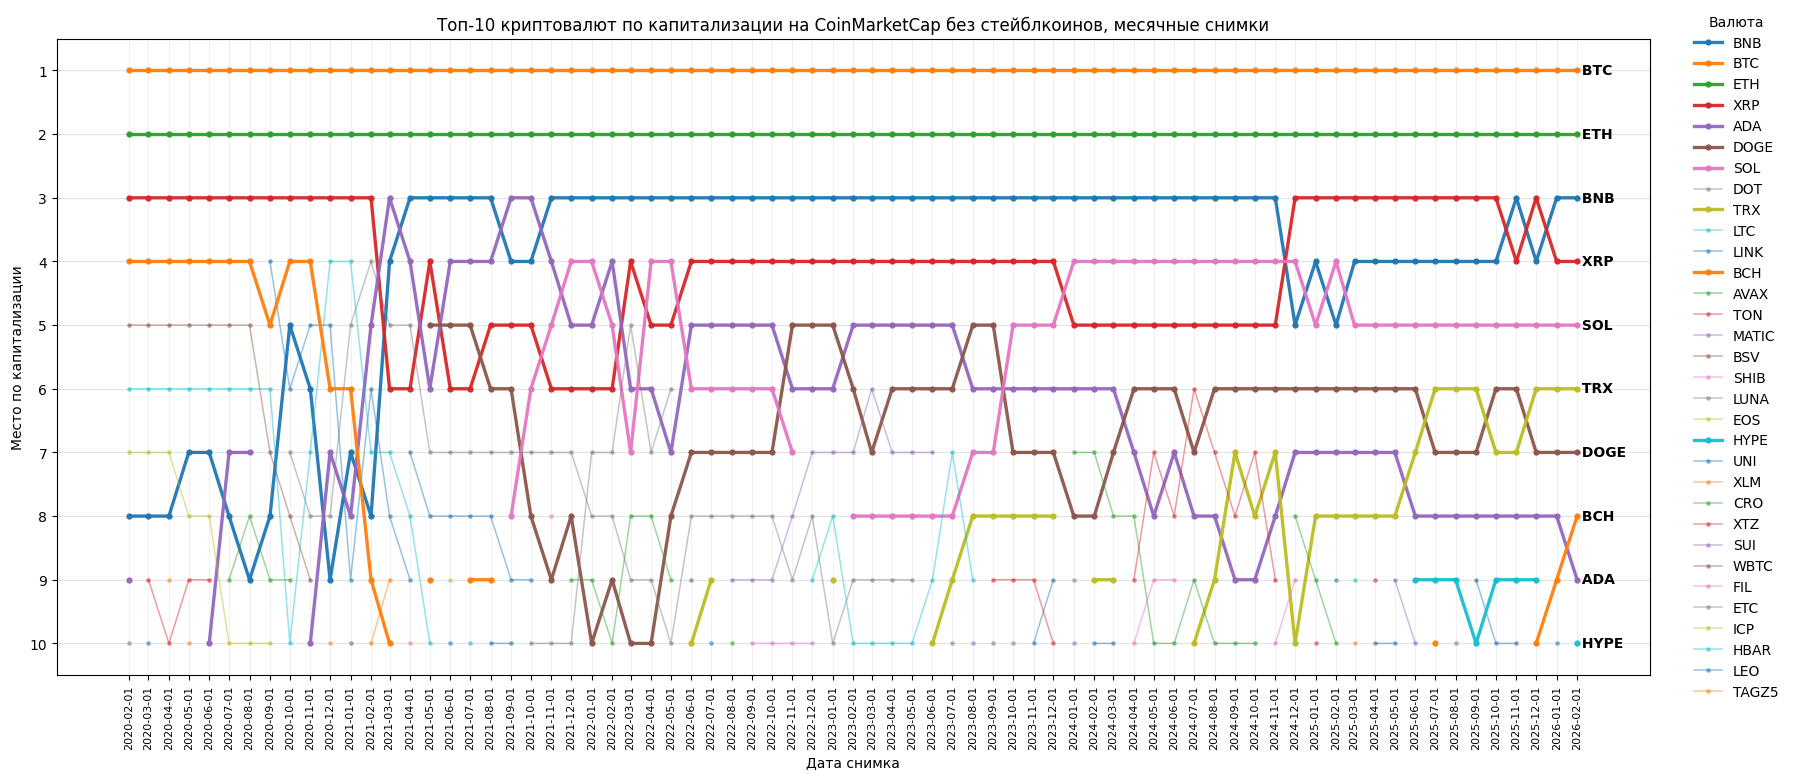

In [103]:
import matplotlib.dates as mdates

# plot_rank_matrix = rank_matrix_no_stables
# plot_symbols = symbols_no_stables

fig, ax = plt.subplots(figsize=(18, 8))

last_snapshot_date = plot_rank_matrix.index.max()
last_top_symbols = (
    plot_rank_matrix.loc[last_snapshot_date]
    .dropna()
    .sort_values()
    .index
    .tolist()
)

for symbol in plot_symbols:
    series = plot_rank_matrix[symbol]
    is_current_top = symbol in last_top_symbols
    ax.plot(
        plot_rank_matrix.index,
        series,
        marker="o",
        linewidth=2.4 if is_current_top else 1.1,
        markersize=3.5 if is_current_top else 2.4,
        alpha=0.95 if is_current_top else 0.45,
        label=symbol,
    )

# Подписываем справа только монеты из последнего топ-10.
for symbol in last_top_symbols:
    series = plot_rank_matrix[symbol].dropna()
    if not series.empty:
        ax.text(
            series.index[-1],
            series.iloc[-1],
            f" {symbol}",
            va="center",
            fontsize=10,
            fontweight="bold",
        )

ax.set_title("Топ-10 криптовалют по капитализации на CoinMarketCap без стейблкоинов, месячные снимки")
ax.set_xlabel("Дата снимка")
ax.set_ylabel("Место по капитализации")
ax.set_yticks(range(1, 11))
ax.set_ylim(10.5, 0.5)

ax.set_xticks(plot_rank_matrix.index)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

for label in ax.get_xticklabels():
    label.set_rotation(90)
    label.set_ha("center")
    label.set_fontsize(8)

ax.grid(True, axis="y", alpha=0.35, linewidth=0.8)
ax.grid(True, axis="x", alpha=0.22, linewidth=0.6)

ax.legend(
    title="Валюта",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    ncol=1,
    frameon=False,
)

fig.tight_layout()
plt.show()

In [101]:
# Optional diagnostics if some monthly snapshots failed.
errors_df

""
